In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

In [3]:
base_path = '/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'

data = []

for class_name in ['benign', 'malignant', 'normal']:
    class_dir = os.path.join(base_path, class_name)
    for filename in os.listdir(class_dir):
        
        if filename.endswith('.png') and '_mask' not in filename:
            data.append({
                'filepath': os.path.join(class_dir, filename),
                'class': class_name
            })

df = pd.DataFrame(data)
print(f"Total images loaded: {len(df)}")
df.head()

Total images loaded: 780


,filepath,class
0,/kaggle/input/datasets/subhajournal/busi-breas...,benign
1,/kaggle/input/datasets/subhajournal/busi-breas...,benign
2,/kaggle/input/datasets/subhajournal/busi-breas...,benign
3,/kaggle/input/datasets/subhajournal/busi-breas...,benign
4,/kaggle/input/datasets/subhajournal/busi-breas...,benign


In [4]:
class_counts = df['class'].value_counts().reindex(['benign', 'malignant', 'normal'])

print("=" * 35)
print(f"{'Class':<15} {'Count':>10}")
print("=" * 35)
for cls, count in class_counts.items():
    print(f"{cls:<15} {count:>10}")
print("=" * 35)
print(f"{'Total':<15} {class_counts.sum():>10}")

Class                Count
benign                 437
malignant              210
normal                 133
Total                  780


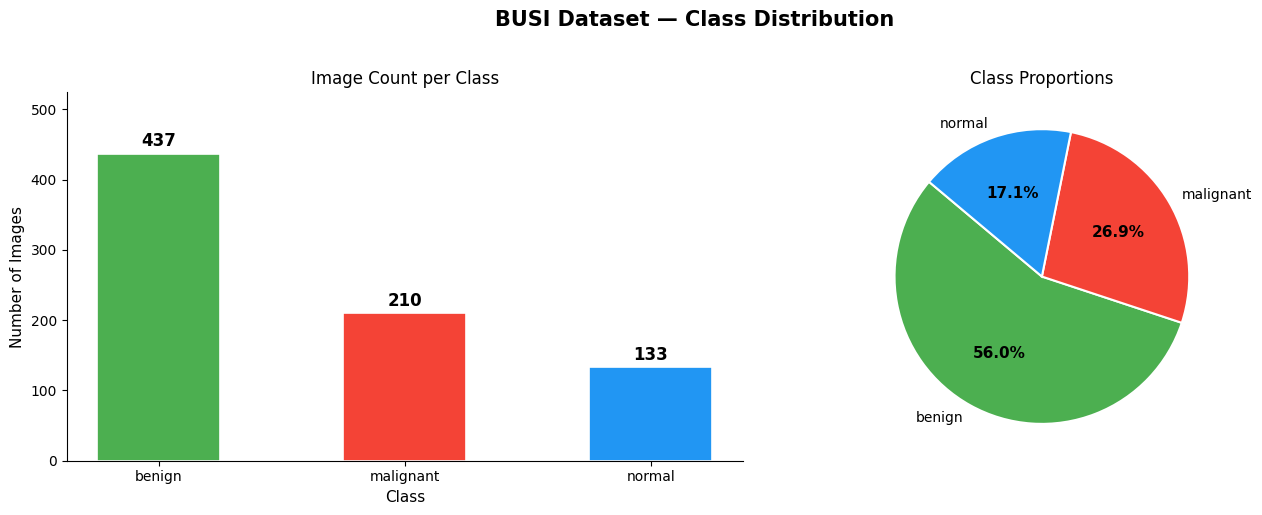

Plot saved to /kaggle/working/class_distribution.png


In [5]:
colors = {'benign': '#4CAF50', 'malignant': '#F44336', 'normal': '#2196F3'}
bar_colors = [colors[cls] for cls in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BUSI Dataset — Class Distribution', fontsize=15, fontweight='bold', y=1.02)

bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('Image Count per Class', fontsize=12)
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Number of Images', fontsize=11)
axes[0].set_ylim(0, class_counts.max() * 1.2)


for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].spines[['top', 'right']].set_visible(False)

wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=bar_colors,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

axes[1].set_title('Class Proportions', fontsize=12)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to /kaggle/working/class_distribution.png")

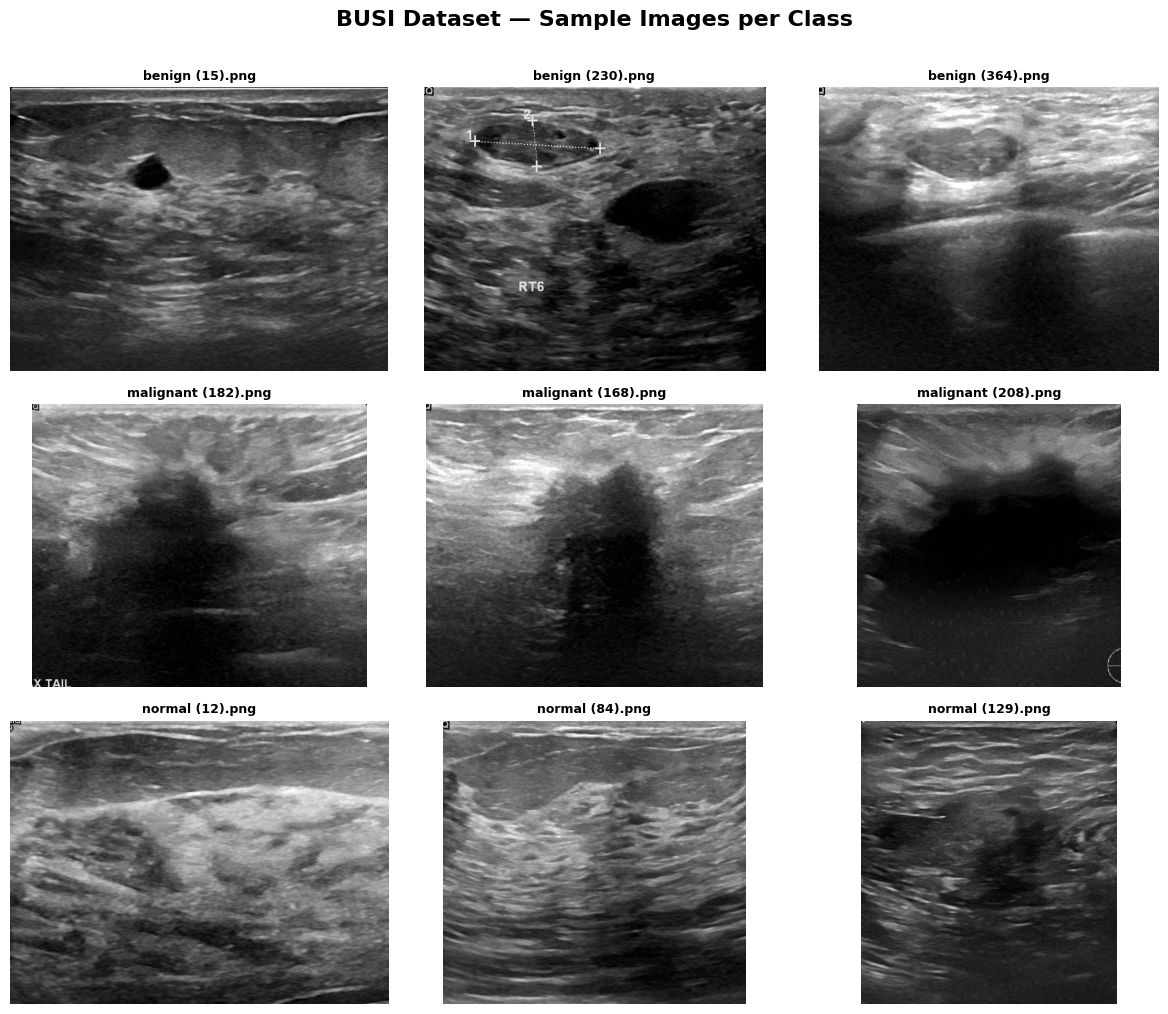

Plot saved to /kaggle/working/sample_images.png


In [6]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


samples_per_class = 3
classes = ['benign', 'malignant', 'normal']

fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(12, 10))
fig.suptitle('BUSI Dataset — Sample Images per Class', fontsize=16, fontweight='bold', y=1.01)

for row, class_name in enumerate(classes):
    
    class_images = df[df['class'] == class_name]['filepath'].tolist()
    
    
    samples = random.sample(class_images, min(samples_per_class, len(class_images)))
    
    for col, img_path in enumerate(samples):
        ax = axes[row][col]
        img = mpimg.imread(img_path)
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        
        
        if col == 0:
            ax.set_ylabel(class_name.capitalize(), fontsize=15,
                          fontweight='bold', rotation=90,
                          labelpad=15, color='white',
                          bbox=dict(boxstyle='round,pad=0.5',
                                    facecolor={'benign':'#4CAF50',
                                               'malignant':'#F44336',
                                               'normal':'#2196F3'}[class_name],
                                    edgecolor='none'))
        
        
        ax.set_title(os.path.basename(img_path), fontsize=9,
                     fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to /kaggle/working/sample_images.png")

In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df['class'])


train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Summary table
print("=" * 50)
print(f"{'Class':<15} {'Train':>10} {'Test':>10} {'Total':>10}")
print("=" * 50)
for cls in ['benign', 'malignant', 'normal']:
    tr = (train_df['class'] == cls).sum()
    te = (test_df['class']  == cls).sum()
    print(f"{cls:<15} {tr:>10} {te:>10} {tr+te:>10}")
print("=" * 50)
print(f"{'Total':<15} {len(train_df):>10} {len(test_df):>10} {len(df):>10}")
print("=" * 50)

Class                Train       Test      Total
benign                 371         66        437
malignant              179         31        210
normal                 113         20        133
Total                  663        117        780


/tmp/ipykernel_57/166027408.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(classes, fontsize=11, fontweight='bold')


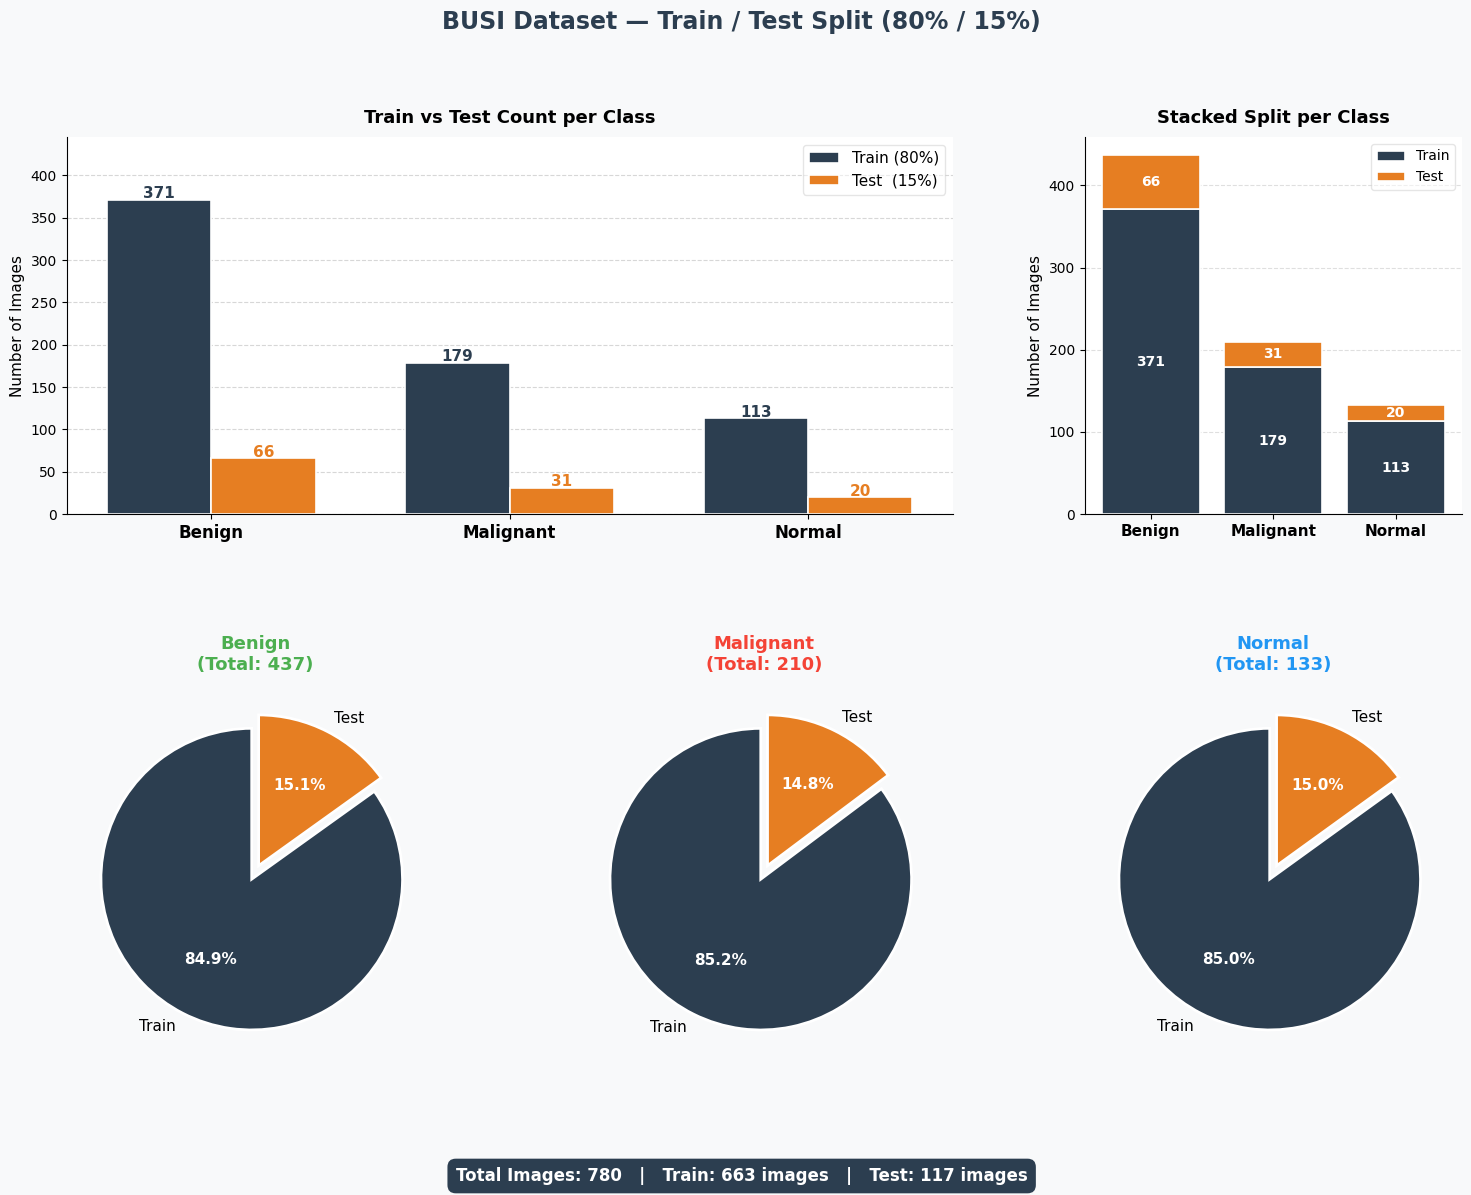

Plot saved to /kaggle/working/train_test_split.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

classes      = ['Benign', 'Malignant', 'Normal']
train_counts = [( train_df['class'] == c.lower()).sum() for c in classes]
test_counts  = [(test_df['class']  == c.lower()).sum() for c in classes]
total_counts = [t + v for t, v in zip(train_counts, test_counts)]

class_colors = {'Benign': '#4CAF50', 'Malignant': '#F44336', 'Normal': '#2196F3'}
train_color  = '#2C3E50'
test_color   = '#E67E22'

x     = np.arange(len(classes))
width = 0.35

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#F8F9FA')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Title ──────────────────────────────────────────────────────────────────
fig.text(0.5, 0.97, 'BUSI Dataset — Train / Test Split (80% / 15%)',
         ha='center', fontsize=17, fontweight='bold', color='#2C3E50')

# ── 1. Grouped Bar Chart ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#FFFFFF')

bars1 = ax1.bar(x - width/2, train_counts, width, label='Train (80%)',
                color=train_color, edgecolor='white', linewidth=1.2)
bars2 = ax1.bar(x + width/2, test_counts,  width, label='Test  (15%)',
                color=test_color,  edgecolor='white', linewidth=1.2)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(int(bar.get_height())), ha='center', fontsize=11,
             fontweight='bold', color=train_color)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(int(bar.get_height())), ha='center', fontsize=11,
             fontweight='bold', color=test_color)

ax1.set_xticks(x)
ax1.set_xticklabels(classes, fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Images', fontsize=11)
ax1.set_title('Train vs Test Count per Class', fontsize=13, fontweight='bold', pad=10)
ax1.legend(fontsize=11, framealpha=0.5)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_ylim(0, max(train_counts) * 1.2)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)


ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#FFFFFF')

b1 = ax2.bar(classes, train_counts, color=train_color,
             edgecolor='white', linewidth=1.2, label='Train')
b2 = ax2.bar(classes, test_counts,  bottom=train_counts,
             color=test_color, edgecolor='white', linewidth=1.2, label='Test')

for i, (tr, te) in enumerate(zip(train_counts, test_counts)):
    ax2.text(i, tr / 2,            str(tr), ha='center', va='center',
             fontsize=10, fontweight='bold', color='white')
    ax2.text(i, tr + te / 2,       str(te), ha='center', va='center',
             fontsize=10, fontweight='bold', color='white')

ax2.set_title('Stacked Split per Class', fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel('Number of Images', fontsize=11)
ax2.set_xticklabels(classes, fontsize=11, fontweight='bold')
ax2.legend(fontsize=10, framealpha=0.5)
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)


for i, cls in enumerate(classes):
    ax = fig.add_subplot(gs[1, i])
    ax.set_facecolor('#FFFFFF')

    sizes  = [train_counts[i], test_counts[i]]
    colors = [train_color, test_color]
    explode = (0.05, 0.05)

    wedges, texts, autotexts = ax.pie(
        sizes, labels=['Train', 'Test'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=explode,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight('bold')
        at.set_color('white')
    for t in texts:
        t.set_fontsize(11)

    ax.set_title(f'{cls}\n(Total: {total_counts[i]})',
                 fontsize=13, fontweight='bold',
                 color=list(class_colors.values())[i], pad=10)


fig.text(0.5, 0.01,
         f"Total Images: {len(df)}   |   Train: {len(train_df)} images   |   Test: {len(test_df)} images",
         ha='center', fontsize=12, fontweight='bold', color='white',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#2C3E50', edgecolor='none'))

plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Plot saved to /kaggle/working/train_test_split.png")

In [9]:
!pip install timm albumentations -q

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import itertools, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

✅ Device: cuda


In [11]:
def add_speckle_noise(image, intensity=0.1):
    """Speckle noise caused by coherent interference of ultrasound waves"""
    noise = np.random.randn(*image.shape) * intensity * 255
    return np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def simulate_acoustic_shadow(image, shadow_width_ratio=0.15):
    """Acoustic shadowing behind highly reflective structures"""
    h, w = image.shape[:2]
    shadow_w = int(w * shadow_width_ratio)
    x_start  = np.random.randint(0, w - shadow_w)
    mask     = np.ones_like(image, dtype=np.float32)
    mask[:, x_start:x_start + shadow_w] = np.random.uniform(0.2, 0.5)
    return np.clip(image * mask, 0, 255).astype(np.uint8)

def simulate_gain_variation(image):
    """Time-gain compensation variation along depth axis"""
    h = image.shape[0]
    gain = np.linspace(np.random.uniform(0.6, 0.9),
                       np.random.uniform(1.0, 1.3), h)
    gain_map = np.tile(gain[:, np.newaxis], (1, image.shape[1]))
    if len(image.shape) == 3:
        gain_map = gain_map[:, :, np.newaxis]
    return np.clip(image * gain_map, 0, 255).astype(np.uint8)

def get_train_transforms(img_size=224):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=20, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.ElasticTransform(alpha=1, sigma=10, p=0.3),
        A.GridDistortion(p=0.2),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_val_transforms(img_size=224):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

print("✅ Physics-informed augmentation pipeline ready.")

✅ Physics-informed augmentation pipeline ready.


In [13]:
def extract_edge_map(image_np):
    """Sobel edge map highlights lesion boundaries for the second stream"""
    gray   = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    sx     = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy     = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    edge   = np.sqrt(sx**2 + sy**2)
    edge   = np.clip(edge / (edge.max() + 1e-8) * 255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(edge, cv2.COLOR_GRAY2RGB)

class BUSIDataset(Dataset):
    def __init__(self, dataframe, transform=None, apply_physics_aug=False):
        self.df                = dataframe.reset_index(drop=True)
        self.transform         = transform
        self.apply_physics_aug = apply_physics_aug
        self.label_map         = {'benign': 0, 'malignant': 1, 'normal': 2}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['filepath'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Physics-informed augmentation (training only)
        if self.apply_physics_aug:
            r = np.random.random()
            if   r < 0.33: img = add_speckle_noise(img, np.random.uniform(0.05, 0.15))
            elif r < 0.66: img = simulate_acoustic_shadow(img)
            else:          img = simulate_gain_variation(img)

        edge = extract_edge_map(img)
        label = self.label_map[row['class']]

        if self.transform:
            img_t  = self.transform(image=img)['image']
            edge_t = self.transform(image=edge)['image']
        else:
            img_t  = torch.tensor(img).permute(2,0,1).float() / 255.
            edge_t = torch.tensor(edge).permute(2,0,1).float() / 255.

        return img_t, edge_t, torch.tensor(label, dtype=torch.long)

print("✅ Dual-stream dataset class ready.")

✅ Dual-stream dataset class ready.


In [14]:
class CrossAttentionFusion(nn.Module):
    """
    Fuses features from two streams using cross-attention.
    Stream 1 queries Stream 2, forcing the model to find
    which boundary features are relevant to each texture region.
    """
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.scale     = (dim // num_heads) ** -0.5
        self.q    = nn.Linear(dim, dim)
        self.k    = nn.Linear(dim, dim)
        self.v    = nn.Linear(dim, dim)
        self.proj = nn.Linear(dim, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x, y):
        # x = texture (query), y = edge (key/value)
        B, C   = x.shape
        H      = self.num_heads
        D      = C // H
        q      = self.q(x).reshape(B, H, D)
        k      = self.k(y).reshape(B, H, D)
        v      = self.v(y).reshape(B, H, D)
        attn   = (q * k).sum(-1) * self.scale           # (B, H)
        attn   = attn.softmax(dim=-1).unsqueeze(-1)      # (B, H, 1)
        out    = (attn * v).reshape(B, C)
        return self.norm(self.proj(out) + x)             # residual


class HADSNet(nn.Module):
    """
    Hybrid Attention-Augmented Dual-Stream Network (HADS-Net)
    ─────────────────────────────────────────────────────────
    Stream 1 : EfficientNet-B3  → global texture features
    Stream 2 : Lightweight CNN  → local boundary features
    Fusion   : Cross-Attention  → guided feature interaction
    Head     : MLP classifier
    """
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()

        # Stream 1 — pretrained backbone
        self.stream1 = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)
        s1_dim       = self.stream1.num_features   # 1536

        # Stream 2 — lightweight boundary CNN
        self.stream2 = nn.Sequential(
            nn.Conv2d(3,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        s2_dim = 256

        # Project to common fusion space
        fusion_dim   = 512
        self.proj1   = nn.Linear(s1_dim, fusion_dim)
        self.proj2   = nn.Linear(s2_dim, fusion_dim)

        # Cross-attention fusion
        self.cross_attn = CrossAttentionFusion(fusion_dim, num_heads=8)

        # Classifier head
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, 256), nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x1, x2):
        f1    = self.stream1(x1)                            # (B, 1536)
        f2    = self.stream2(x2).squeeze(-1).squeeze(-1)    # (B, 256)
        f1    = F.relu(self.proj1(f1))                      # (B, 512)
        f2    = F.relu(self.proj2(f2))                      # (B, 512)
        fused = self.cross_attn(f1, f2)                     # (B, 512)
        return self.head(fused)

# Quick sanity check
_m  = HADSNet(3).to(device)
_x1 = torch.randn(2, 3, 224, 224).to(device)
_x2 = torch.randn(2, 3, 224, 224).to(device)
print(f"✅ HADS-Net output shape: {_m(_x1,_x2).shape}")
del _m, _x1, _x2

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ HADS-Net output shape: torch.Size([2, 3])


In [16]:
class FocalLoss(nn.Module):
    """
    Adaptive Class-Weighted Focal Loss
    Down-weights easy examples so the model focuses on hard/misclassified ones.
    alpha  = inverse-frequency class weights
    gamma  = focusing parameter (2.0 is standard)
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce     = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt     = torch.exp(-ce)
        focal  = ((1 - pt) ** self.gamma) * ce
        return focal.mean()

# Compute inverse-frequency weights from full dataset
counts        = np.array([(df['class'] == c).sum() for c in ['benign','malignant','normal']])
class_weights = torch.tensor(counts.sum() / (3.0 * counts), dtype=torch.float32).to(device)
criterion     = FocalLoss(alpha=class_weights, gamma=2.0)

print(f"Class weights  →  Benign: {class_weights[0]:.3f} | "
      f"Malignant: {class_weights[1]:.3f} | Normal: {class_weights[2]:.3f}")
print("✅ Adaptive Focal Loss ready.")

Class weights  →  Benign: 0.595 | Malignant: 1.238 | Normal: 1.955
✅ Adaptive Focal Loss ready.


In [17]:
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS    = 50
K_FOLDS   = 5
IMG_SIZE  = 224
BATCH     = 32

skf             = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_results    = []
all_val_preds   = []
all_val_labels  = []
all_val_probs   = []


global_best_loss = float('inf')
global_best_fold = None
global_best_ep   = None

for fold, (tr_idx, val_idx) in enumerate(skf.split(np.arange(len(df)), df['class'].values)):
    print(f"\n{'━'*58}")
    print(f"  FOLD {fold+1} / {K_FOLDS}   "
          f"(train={len(tr_idx)}, val={len(val_idx)})")
    print(f"{'━'*58}")

    fold_train = df.iloc[tr_idx]
    fold_val   = df.iloc[val_idx]

    train_ds = BUSIDataset(fold_train, get_train_transforms(IMG_SIZE), apply_physics_aug=True)
    val_ds   = BUSIDataset(fold_val,   get_val_transforms(IMG_SIZE),   apply_physics_aug=False)
    train_loader = DataLoader(train_ds, BATCH, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=2, pin_memory=True)

    model     = HADSNet(num_classes=3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_fold_loss = float('inf')
    history        = {'tl':[], 'vl':[], 'ta':[], 'va':[]}

    for ep in range(EPOCHS):
        
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for x1, x2, y in train_loader:
            x1, x2, y = x1.to(device), x2.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(x1, x2)
            loss = criterion(out, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tl += loss.item() * y.size(0)
            tc += (out.argmax(1) == y).sum().item()
            tt += y.size(0)
        scheduler.step()

       
        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for x1, x2, y in val_loader:
                x1, x2, y = x1.to(device), x2.to(device), y.to(device)
                out  = model(x1, x2)
                loss = criterion(out, y)
                vl  += loss.item() * y.size(0)
                vc  += (out.argmax(1) == y).sum().item()
                vt  += y.size(0)

        ta          = tc / tt
        va          = vc / vt
        avg_vl      = vl / vt
        avg_tl      = tl / tt

        history['tl'].append(avg_tl); history['vl'].append(avg_vl)
        history['ta'].append(ta);     history['va'].append(va)

        
        fold_marker = ""
        if avg_vl < best_fold_loss:
            best_fold_loss = avg_vl
            fold_marker    = " 🔹"

        
        global_marker = ""
        if avg_vl < global_best_loss:
            global_best_loss = avg_vl
            global_best_fold = fold + 1
            global_best_ep   = ep  + 1
            torch.save(model.state_dict(), '/kaggle/working/global_best.pth')
            global_marker = " ⭐ GLOBAL BEST SAVED"

        print(f"  Ep [{ep+1:02d}/{EPOCHS}]  "
              f"Train Loss {avg_tl:.4f}  Acc {ta:.4f}  │  "
              f"Val Loss {avg_vl:.4f}  Acc {va:.4f}"
              f"{fold_marker}{global_marker}")

    
    model.load_state_dict(torch.load('/kaggle/working/global_best.pth'))
    model.eval()
    with torch.no_grad():
        for x1, x2, y in val_loader:
            x1, x2, y = x1.to(device), x2.to(device), y.to(device)
            logits = model(x1, x2)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(1).cpu().numpy()
            all_val_probs.extend(probs)
            all_val_preds.extend(preds)
            all_val_labels.extend(y.cpu().numpy())

    fold_results.append({'fold': fold+1, 'best_loss': best_fold_loss, **history})
    print(f"\n  ✅ Fold {fold+1} Best Val Loss: {best_fold_loss:.4f}")


all_val_preds  = np.array(all_val_preds)
all_val_labels = np.array(all_val_labels)
all_val_probs  = np.array(all_val_probs)

mean_loss = np.mean([r['best_loss'] for r in fold_results])
std_loss  = np.std( [r['best_loss'] for r in fold_results])

print(f"\n{'━'*58}")
print(f"  5-Fold CV Best Val Loss  : {mean_loss:.4f} ± {std_loss:.4f}")
print(f"  Global Best Val Loss     : {global_best_loss:.4f}  "
      f"(Fold {global_best_fold}, Epoch {global_best_ep})")
print(f"  Saved → /kaggle/working/global_best.pth")
print(f"{'━'*58}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FOLD 1 / 5   (train=624, val=156)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ep [01/50]  Train Loss 0.5487  Acc 0.3157  │  Val Loss 0.4517  Acc 0.4423 🔹 ⭐ GLOBAL BEST SAVED
  Ep [02/50]  Train Loss 0.4779  Acc 0.4087  │  Val Loss 0.3461  Acc 0.5513 🔹 ⭐ GLOBAL BEST SAVED
  Ep [03/50]  Train Loss 0.3956  Acc 0.4760  │  Val Loss 0.2574  Acc 0.6154 🔹 ⭐ GLOBAL BEST SAVED
  Ep [04/50]  Train Loss 0.3668  Acc 0.5048  │  Val Loss 0.2077  Acc 0.7115 🔹 ⭐ GLOBAL BEST SAVED
  Ep [05/50]  Train Loss 0.3225  Acc 0.6282  │  Val Loss 0.1778  Acc 0.7179 🔹 ⭐ GLOBAL BEST SAVED
  Ep [06/50]  Train Loss 0.2670  Acc 0.6474  │  Val Loss 0.1605  Acc 0.7628 🔹 ⭐ GLOBAL BEST SAVED
  Ep [07/50]  Train Loss 0.2514  Acc 0.6731  │  Val Loss 0.1555  Acc 0.8077 🔹 ⭐ GLOBAL BEST SAVED
  Ep [08/50]  Train Loss 0.2665  Acc 0.7163  │  Val Loss 0.1419  Acc 0.7500 🔹 ⭐ GLOBAL BEST SAVED
  Ep [09/50]  Train Loss 0.2167  Acc 0.7115  │  Val Loss 0.13

In [19]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import itertools, numpy as np

CLASS_NAMES = ['Benign', 'Malignant', 'Normal']
FOLD_COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']

print("─── Validation Classification Report ───────────────────")
print(classification_report(all_val_labels, all_val_preds, target_names=CLASS_NAMES))

y_bin_val    = label_binarize(all_val_labels, classes=[0,1,2])
val_auc      = roc_auc_score(y_bin_val, all_val_probs, multi_class='ovr', average='macro')
val_macro_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
val_acc      = (all_val_preds == all_val_labels).mean()
mean_loss    = np.mean([r['best_loss'] for r in fold_results])
std_loss     = np.std( [r['best_loss'] for r in fold_results])

print(f"Val Accuracy   : {val_acc:.4f}")
print(f"Macro ROC-AUC  : {val_auc:.4f}")
print(f"Macro F1       : {val_macro_f1:.4f}")
print(f"Mean CV Loss   : {mean_loss:.4f} ± {std_loss:.4f}")
print(f"Global Best    : Fold {global_best_fold} | Epoch {global_best_ep} | Loss {global_best_loss:.4f}")

─── Validation Classification Report ───────────────────
              precision    recall  f1-score   support

      Benign       0.99      0.93      0.96       437
   Malignant       0.89      0.99      0.94       210
      Normal       0.96      1.00      0.98       133

    accuracy                           0.96       780
   macro avg       0.95      0.97      0.96       780
weighted avg       0.96      0.96      0.96       780

Val Accuracy   : 0.9564
Macro ROC-AUC  : 0.9962
Macro F1       : 0.9581
Mean CV Loss   : 0.1075 ± 0.0300
Global Best    : Fold 1 | Epoch 44 | Loss 0.0693


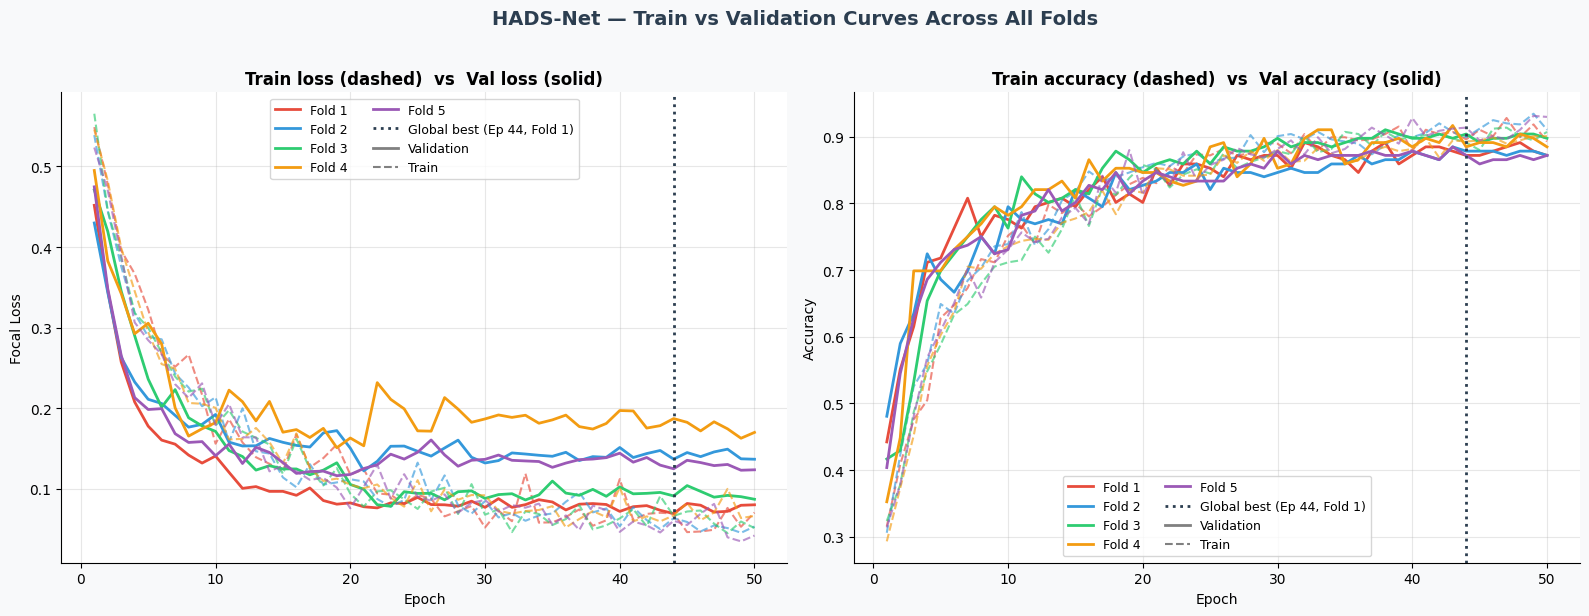

✅ Saved → /kaggle/working/all_folds_curves.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('HADS-Net — Train vs Validation Curves Across All Folds',
             fontsize=14, fontweight='bold', color='#2C3E50', y=1.02)

ep_x = range(1, EPOCHS + 1)

for i, r in enumerate(fold_results):
    col = FOLD_COLORS[i]
    lbl = f"Fold {r['fold']}"

    # Loss
    ax1.plot(ep_x, r['tl'], color=col, linestyle='--', linewidth=1.5, alpha=0.65)
    ax1.plot(ep_x, r['vl'], color=col, linestyle='-',  linewidth=2,   label=lbl)

    # Accuracy
    ax2.plot(ep_x, r['ta'], color=col, linestyle='--', linewidth=1.5, alpha=0.65)
    ax2.plot(ep_x, r['va'], color=col, linestyle='-',  linewidth=2,   label=lbl)

# Mark global best epoch
for ax in (ax1, ax2):
    ax.axvline(x=global_best_ep, color='#2C3E50', linestyle=':', linewidth=2,
               label=f'Global best (Ep {global_best_ep}, Fold {global_best_fold})')
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('white')
    ax.set_xlabel('Epoch')

ax1.set_title('Train loss (dashed)  vs  Val loss (solid)', fontweight='bold')
ax1.set_ylabel('Focal Loss')

ax2.set_title('Train accuracy (dashed)  vs  Val accuracy (solid)', fontweight='bold')
ax2.set_ylabel('Accuracy')

# Shared legend
solid_line  = mlines.Line2D([], [], color='gray', linestyle='-',  linewidth=2, label='Validation')
dashed_line = mlines.Line2D([], [], color='gray', linestyle='--', linewidth=1.5, label='Train')
for ax in (ax1, ax2):
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + [solid_line, dashed_line],
              labels  + ['Validation', 'Train'],
              fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('/kaggle/working/all_folds_curves.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved → /kaggle/working/all_folds_curves.png")

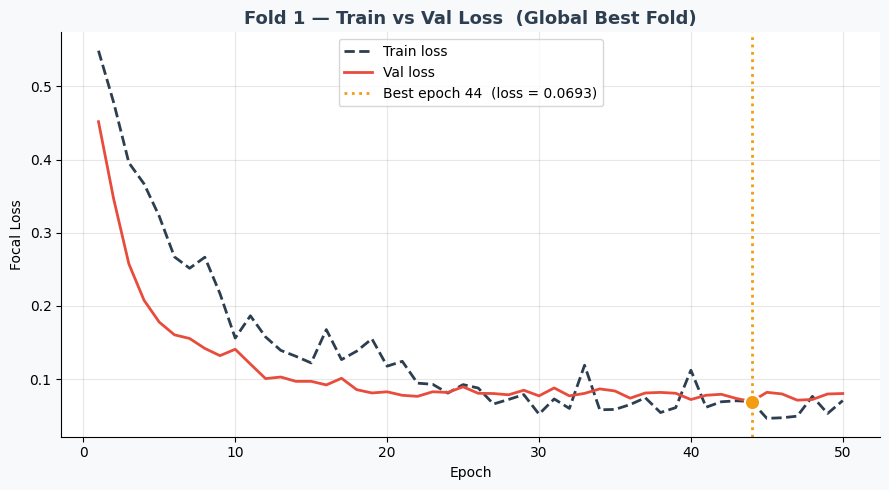

✅ Saved → /kaggle/working/best_fold_loss.png


In [21]:
best_r = next(r for r in fold_results if r['fold'] == global_best_fold)
ep_x   = range(1, EPOCHS + 1)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('white')

ax.plot(ep_x, best_r['tl'], color='#2C3E50', linestyle='--',
        linewidth=2, label='Train loss')
ax.plot(ep_x, best_r['vl'], color='#E74C3C', linestyle='-',
        linewidth=2, label='Val loss')

# Mark the global best epoch
best_ep_loss = best_r['vl'][global_best_ep - 1]
ax.axvline(x=global_best_ep, color='#F39C12', linestyle=':', linewidth=2,
           label=f'Best epoch {global_best_ep}  (loss = {best_ep_loss:.4f})')
ax.scatter([global_best_ep], [best_ep_loss],
           color='#F39C12', s=120, zorder=5, edgecolors='white', linewidths=1.5)

ax.set_title(f'Fold {global_best_fold} — Train vs Val Loss  (Global Best Fold)',
             fontsize=13, fontweight='bold', color='#2C3E50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Focal Loss')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/best_fold_loss.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved → /kaggle/working/best_fold_loss.png")

In [22]:

test_ds     = BUSIDataset(test_df, get_val_transforms(IMG_SIZE), apply_physics_aug=False)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                         num_workers=2, pin_memory=True)


model = HADSNet(num_classes=3).to(device)
model.load_state_dict(torch.load('/kaggle/working/global_best.pth',
                                  map_location=device))
model.eval()

test_preds, test_labels, test_probs = [], [], []

with torch.no_grad():
    for x1, x2, y in test_loader:
        x1, x2, y = x1.to(device), x2.to(device), y.to(device)
        logits = model(x1, x2)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        test_probs.extend(probs)
        test_preds.extend(preds)
        test_labels.extend(y.cpu().numpy())

test_preds  = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs  = np.array(test_probs)

print("─── Test Set Classification Report ─────────────────────")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

y_bin_test    = label_binarize(test_labels, classes=[0,1,2])
test_auc      = roc_auc_score(y_bin_test, test_probs, multi_class='ovr', average='macro')
test_macro_f1 = f1_score(test_labels, test_preds, average='macro')
test_acc      = (test_preds == test_labels).mean()

print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Macro ROC-AUC  : {test_auc:.4f}")
print(f"Macro F1       : {test_macro_f1:.4f}")

─── Test Set Classification Report ─────────────────────
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        66
   Malignant       0.97      0.94      0.95        31
      Normal       0.95      1.00      0.98        20

    accuracy                           0.97       117
   macro avg       0.96      0.97      0.97       117
weighted avg       0.97      0.97      0.97       117

Test Accuracy  : 0.9658
Macro ROC-AUC  : 0.9978
Macro F1       : 0.9654


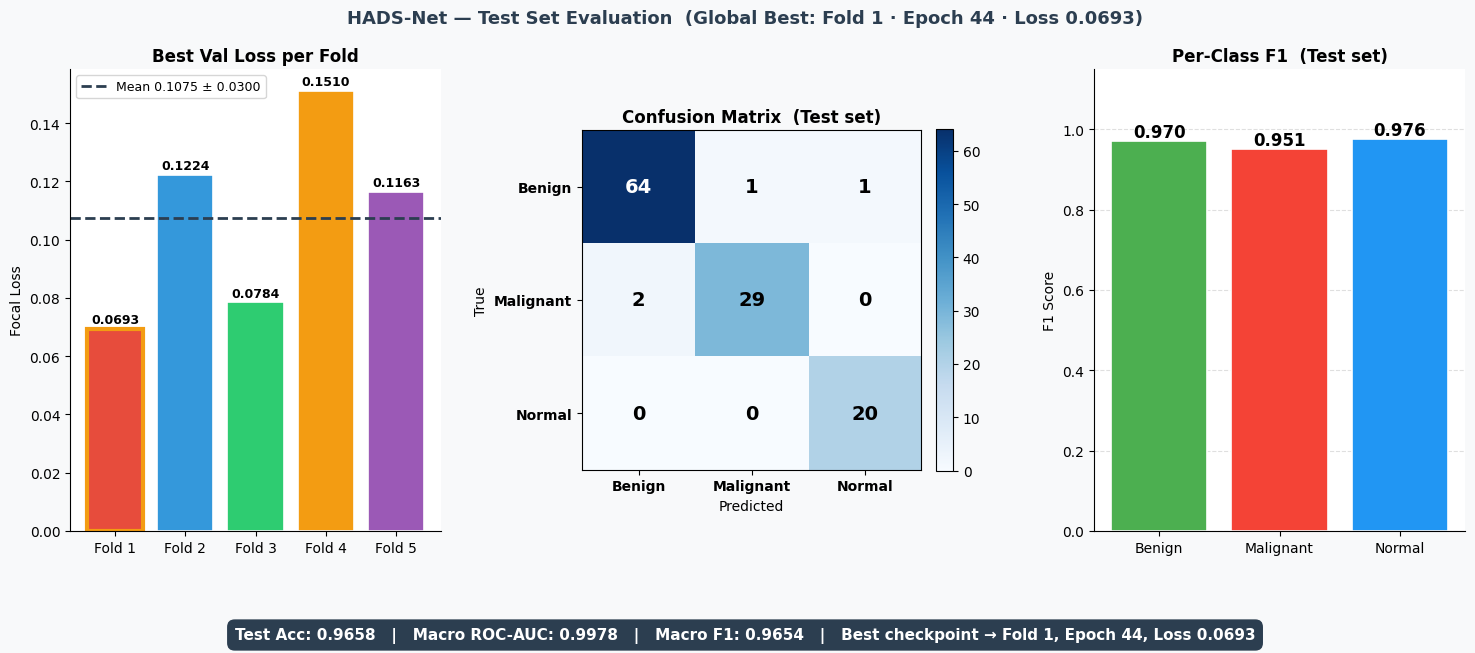

✅ Saved → /kaggle/working/test_evaluation.png


In [23]:
fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor('#F8F9FA')
gs  = plt.GridSpec(1, 3, figure=fig, wspace=0.38)
fig.suptitle(
    f'HADS-Net — Test Set Evaluation  '
    f'(Global Best: Fold {global_best_fold} · Epoch {global_best_ep} · Loss {global_best_loss:.4f})',
    fontsize=13, fontweight='bold', color='#2C3E50')


ax1 = fig.add_subplot(gs[0, 0]); ax1.set_facecolor('white')
best_losses = [r['best_loss'] for r in fold_results]
bars = ax1.bar([f"Fold {r['fold']}" for r in fold_results],
               best_losses, color=FOLD_COLORS, edgecolor='white', linewidth=1.2)


bars[global_best_fold - 1].set_edgecolor('#F39C12')
bars[global_best_fold - 1].set_linewidth(3)

for b, l in zip(bars, best_losses):
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.002,
             f'{l:.4f}', ha='center', fontsize=9, fontweight='bold')

ax1.axhline(mean_loss, color='#2C3E50', linestyle='--', linewidth=2,
            label=f'Mean {mean_loss:.4f} ± {std_loss:.4f}')
ax1.set_title('Best Val Loss per Fold', fontweight='bold')
ax1.set_ylabel('Focal Loss')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# ── 2. Confusion matrix on TEST set ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cm     = confusion_matrix(test_labels, test_preds)
im     = ax2.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
ax2.set_xticks(range(3)); ax2.set_yticks(range(3))
ax2.set_xticklabels(CLASS_NAMES, fontsize=10, fontweight='bold')
ax2.set_yticklabels(CLASS_NAMES, fontsize=10, fontweight='bold')
thresh = cm.max() / 2
for i, j in itertools.product(range(3), range(3)):
    ax2.text(j, i, str(cm[i, j]), ha='center', va='center',
             fontsize=14, fontweight='bold',
             color='white' if cm[i, j] > thresh else 'black')
ax2.set_title('Confusion Matrix  (Test set)', fontweight='bold')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')

# ── 3. Per-class F1 on TEST set ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2]); ax3.set_facecolor('white')
f1s  = f1_score(test_labels, test_preds, average=None)
cols = ['#4CAF50', '#F44336', '#2196F3']
bars = ax3.bar(CLASS_NAMES, f1s, color=cols, edgecolor='white', linewidth=1.2)
for b, f in zip(bars, f1s):
    ax3.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
             f'{f:.3f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_title('Per-Class F1  (Test set)', fontweight='bold')
ax3.set_ylabel('F1 Score'); ax3.set_ylim(0, 1.15)
ax3.yaxis.grid(True, linestyle='--', alpha=0.4); ax3.set_axisbelow(True)
ax3.spines[['top', 'right']].set_visible(False)

# ── Footer ─────────────────────────────────────────────────────────────────
fig.text(0.5, -0.07,
         f"Test Acc: {test_acc:.4f}   |   "
         f"Macro ROC-AUC: {test_auc:.4f}   |   "
         f"Macro F1: {test_macro_f1:.4f}   |   "
         f"Best checkpoint → Fold {global_best_fold}, Epoch {global_best_ep}, Loss {global_best_loss:.4f}",
         ha='center', fontsize=11, fontweight='bold', color='white',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#2C3E50', edgecolor='none'))

plt.savefig('/kaggle/working/test_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved → /kaggle/working/test_evaluation.png")